In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("C:/Users/hp/Downloads/agricultural_crop_yield_regression/crop_yield.csv")
df.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909


In [4]:
df.shape

(19689, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 1.5+ MB


In [6]:
print('Duplicates:', df.duplicated().sum())

Duplicates: 0


In [7]:
df.isnull().sum()

Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
dtype: int64

In [8]:
#df['Crop'].value_counts()
#df['State'].value_counts()
df['Season'].value_counts()

Season
Kharif         8232
Rabi           5742
Whole Year     3717
Summer         1195
Autumn          414
Winter          389
Name: count, dtype: int64

In [9]:
df.describe()

,Crop_Year,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
count,19689.000000,1.968900e+04,1.968900e+04,19689.000000,1.968900e+04,1.968900e+04,19689.000000
mean,2009.127584,1.799266e+05,1.643594e+07,1437.755177,2.410331e+07,4.884835e+04,79.954009
std,6.498099,7.328287e+05,2.630568e+08,816.909589,9.494600e+07,2.132874e+05,878.306193
min,1997.000000,5.000000e-01,0.000000e+00,301.300000,5.417000e+01,9.000000e-02,0.000000
25%,2004.000000,1.390000e+03,1.393000e+03,940.700000,1.880146e+05,3.567000e+02,0.600000
50%,2010.000000,9.317000e+03,1.380400e+04,1247.600000,1.234957e+06,2.421900e+03,1.030000
75%,2015.000000,7.511200e+04,1.227180e+05,1643.700000,1.000385e+07,2.004170e+04,2.388889
max,2020.000000,5.080810e+07,6.326000e+09,6552.700000,4.835407e+09,1.575051e+07,21105.000000


### 1D EDA

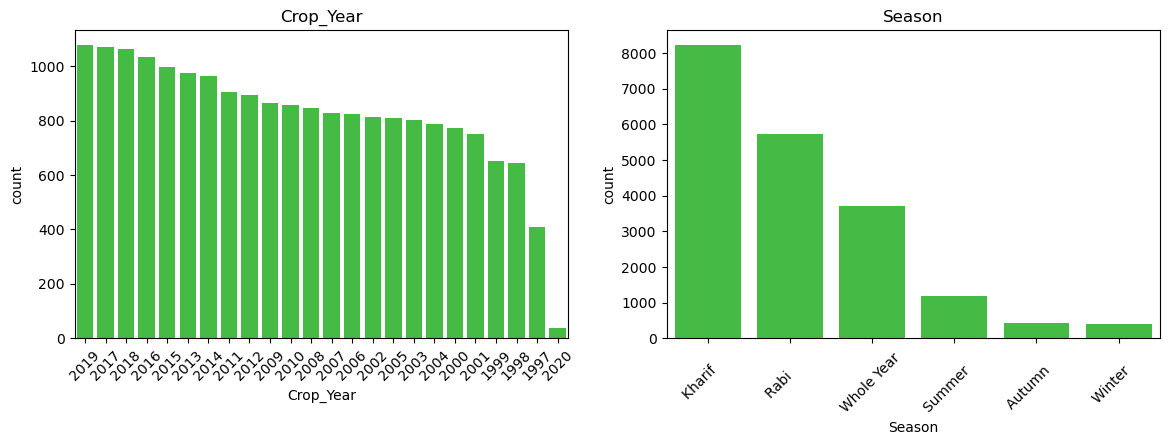

In [10]:
col = ['Crop','Crop_Year','Season','State']

plt.figure(figsize=(14,4))
i = 1
for col in ['Crop_Year','Season']:
    plt.subplot(1,2,i)
    sns.countplot(x=df[col], order=df[col].value_counts().index, color='limegreen')
    plt.title(col)
    plt.xticks(rotation=45)
    i+=1
plt.show()

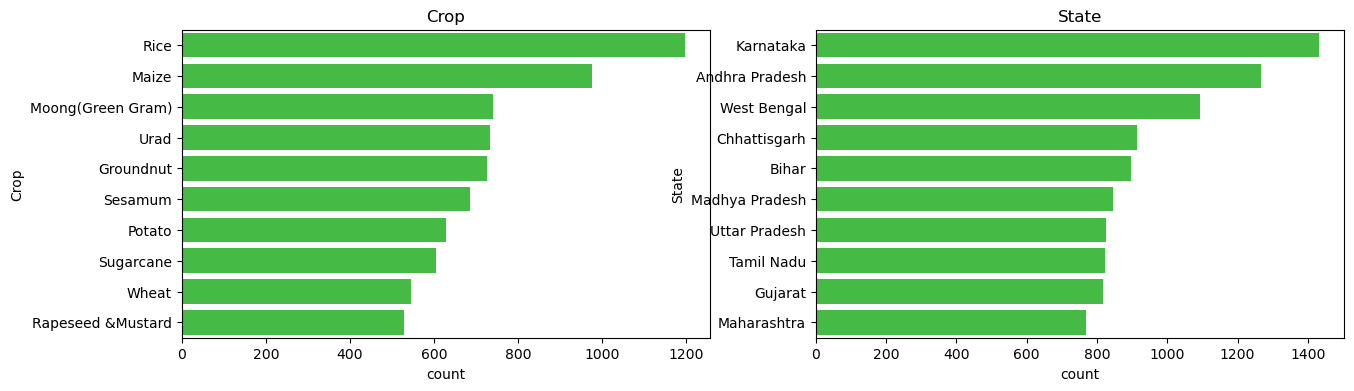

In [11]:
plt.figure(figsize=(15,4))
i = 1
for col in ['Crop','State']:
    plt.subplot(1,2,i)
    sns.countplot(y=df[col], order=df[col].value_counts().head(10).index, color='limegreen')
    plt.title(col)
    i+=1
plt.show()

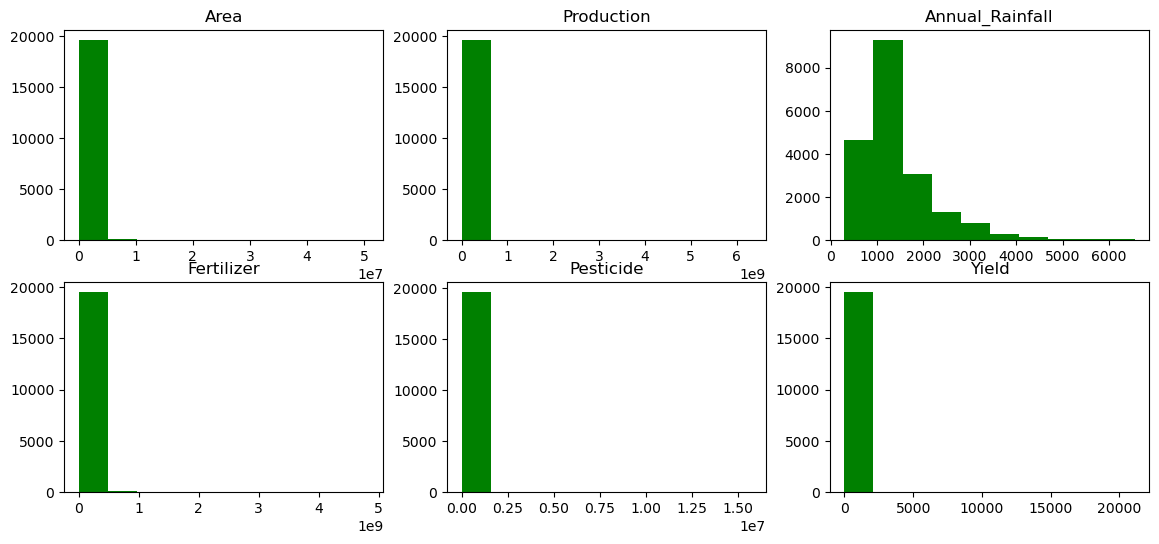

In [19]:
cols = ['Area','Production','Annual_Rainfall','Fertilizer','Pesticide','Yield']

plt.figure(figsize=(14,6))
i = 1

for col in cols:
    plt.subplot(2,3,i)
    plt.hist(df[col], color='green')
    plt.title(col)
    i+=1

plt.show()

In [20]:
skewed_cols = ['Area', 'Fertilizer', 'Pesticide', 'Annual_Rainfall', 'Yield']

for col in skewed_cols:
    df[col] = np.log1p(df[col])

In [21]:
df[['Area','Fertilizer','Pesticide','Yield','Annual_Rainfall']].skew()

Area              -0.340852
Fertilizer        -0.383779
Pesticide         -0.257160
Yield              3.660985
Annual_Rainfall    0.077752
dtype: float64

### 2D EDA

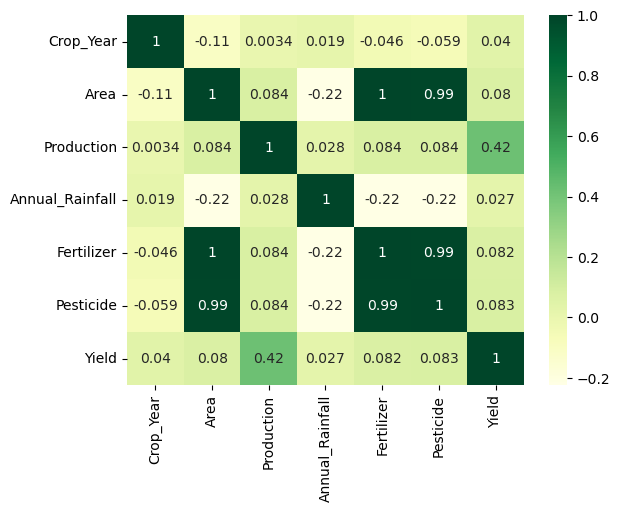

In [22]:
num_df = df.select_dtypes(include=[np.number]) #np.number includes both int and float
correlation_matrix = num_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='YlGn')
plt.show()

#### Crop-wise

In [23]:
crop_wise_area = df.groupby('Crop')['Area'].sum()
sorted_crop_wise_area = crop_wise_area.sort_values(ascending=False).head(15)

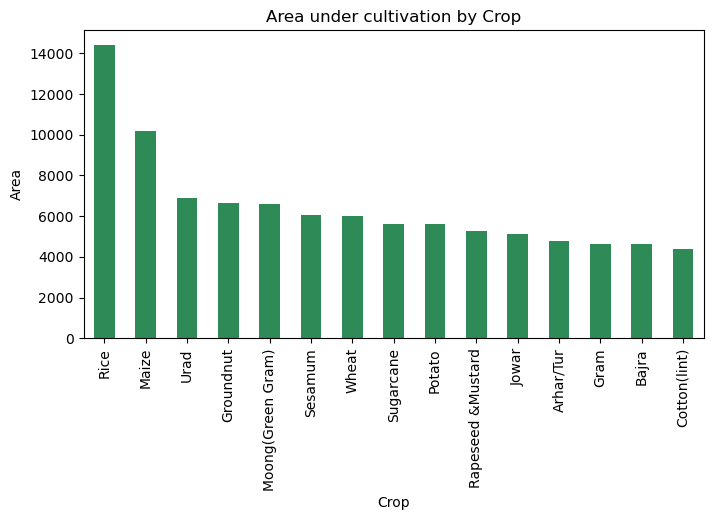

In [24]:
plt.figure(figsize=(8,4))
sorted_crop_wise_area.plot(kind='bar', color='seagreen')
plt.xlabel('Crop')
plt.ylabel('Area')
plt.title('Area under cultivation by Crop')
plt.show()

In [25]:
crop_wise_prod = df.groupby('Crop')['Production'].sum()
crop_wise_prod.sort_values(ascending=False).reset_index().head(10)

,Crop,Production
0,Coconut,308751970278
1,Sugarcane,7236536755
2,Rice,2229301180
3,Wheat,1810754504
4,Potato,629688035
5,Cotton(lint),457831414
6,Maize,410911181
7,Jute,230423821
8,Banana,226471979
9,Soyabean,191659664


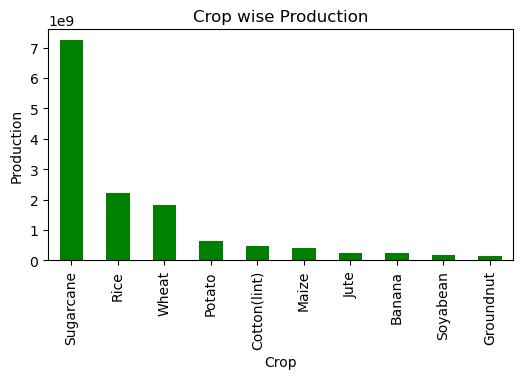

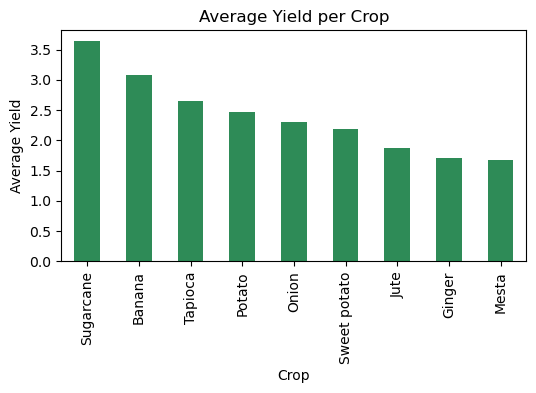

In [26]:
x = crop_wise_prod.drop('Coconut ')
plt.figure(figsize=(6,3))
x.sort_values(ascending=False).head(10).plot(kind='bar', color='green')
plt.title('Crop wise Production')
plt.xlabel('Crop')
plt.ylabel('Production')
plt.show()

yield_per_crop = df.groupby('Crop')['Yield'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(6,3))
yield_per_crop.drop('Coconut ').plot(kind='bar', color='seagreen')
plt.title('Average Yield per Crop')
plt.xlabel('Crop')
plt.ylabel('Average Yield')
plt.show()

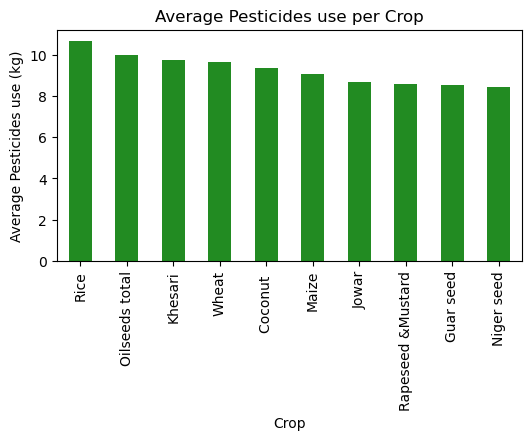

In [27]:
pesticide_per_crop = df.groupby('Crop')['Pesticide'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(6,3))
pesticide_per_crop.plot(kind='bar', color='forestgreen')
plt.title('Average Pesticides use per Crop')
plt.xlabel('Crop')
plt.ylabel('Average Pesticides use (kg)')
plt.show()

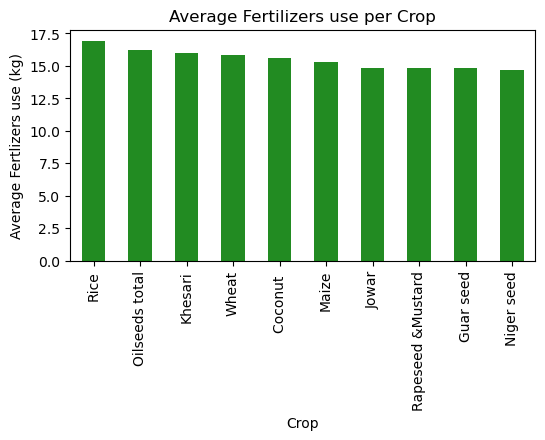

In [28]:
fertilizers_per_crop = df.groupby('Crop')['Fertilizer'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(6,3))
fertilizers_per_crop.plot(kind='bar', color='forestgreen')
plt.title('Average Fertilizers use per Crop')
plt.xlabel('Crop')
plt.ylabel('Average Fertlizers use (kg)')
plt.show()

#### Year-wise

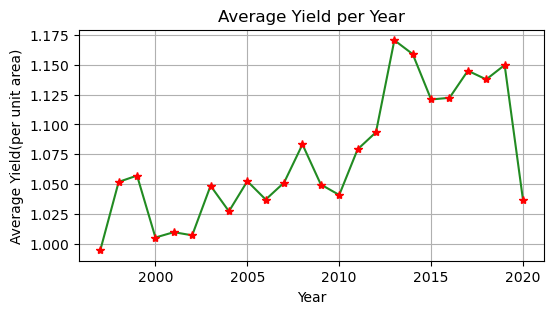

In [29]:
yield_per_year = df.groupby('Crop_Year')['Yield'].mean()

plt.figure(figsize=(6,3))
yield_per_year.plot(kind='line', color='forestgreen', marker='*', mec='r', mfc='r')
plt.title('Average Yield per Year')
plt.xlabel('Year')
plt.ylabel('Average Yield(per unit area)')
plt.grid()
plt.show()

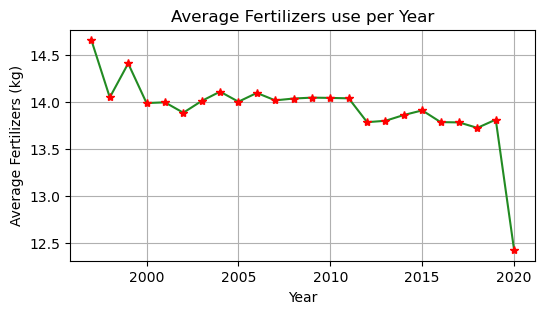

In [30]:
fert_per_year = df.groupby('Crop_Year')['Fertilizer'].mean()

plt.figure(figsize=(6,3))
fert_per_year.plot(kind='line', color='forestgreen', marker='*', mec='r', mfc='r')
plt.title('Average Fertilizers use per Year')
plt.xlabel('Year')
plt.ylabel('Average Fertilizers (kg)')
plt.grid()
plt.show()

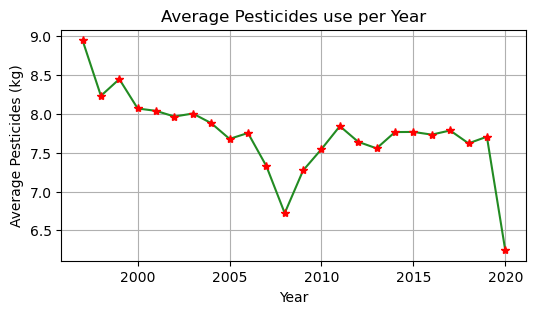

In [31]:
pest_per_year = df.groupby('Crop_Year')['Pesticide'].mean()

plt.figure(figsize=(6,3))
pest_per_year.plot(kind='line', color='forestgreen', marker='*', mec='r', mfc='r')
plt.title('Average Pesticides use per Year')
plt.xlabel('Year')
plt.ylabel('Average Pesticides (kg)')
plt.grid()
plt.show()

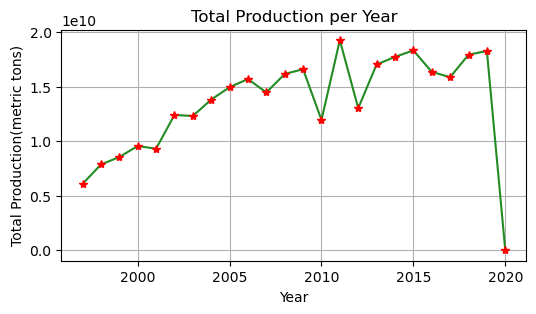

In [32]:
prod_per_year = df.groupby('Crop_Year')['Production'].sum()

plt.figure(figsize=(6,3))
prod_per_year.plot(kind='line', color='forestgreen', marker='*', mec='r', mfc='r')
plt.title('Total Production per Year')
plt.xlabel('Year')
plt.ylabel('Total Production(metric tons)')
plt.grid()
plt.show()

#### Season wise

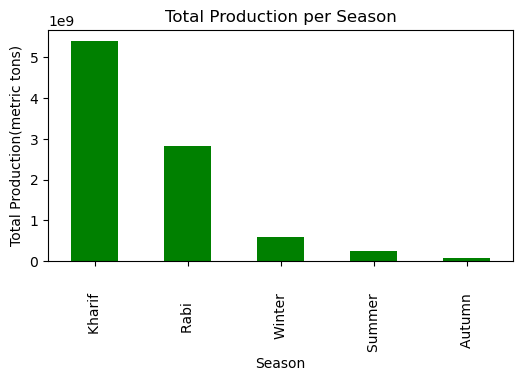

In [33]:
# crops produced whole year have more very large production
prod_per_season = df.groupby('Season')['Production'].sum().sort_values(ascending=False)

plt.figure(figsize=(6,3))
prod_per_season.drop('Whole Year ').plot(kind='bar', color='green')
plt.title('Total Production per Season')
plt.xlabel('Season')
plt.ylabel('Total Production(metric tons)')
plt.show()

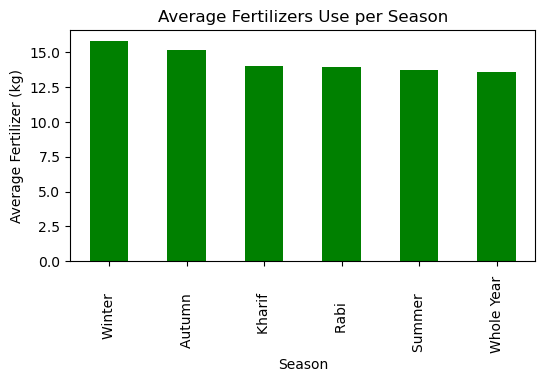

In [34]:
fer_per_season = df.groupby('Season')['Fertilizer'].mean().sort_values(ascending=False)

plt.figure(figsize=(6,3))
fer_per_season.plot(kind='bar', color='green')
plt.title('Average Fertilizers Use per Season')
plt.xlabel('Season')
plt.ylabel('Average Fertilizer (kg)')
plt.show()

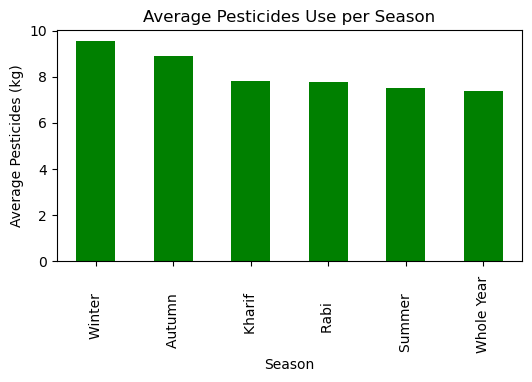

In [35]:
pest_per_season = df.groupby('Season')['Pesticide'].mean().sort_values(ascending=False)

plt.figure(figsize=(6,3))
pest_per_season.plot(kind='bar', color='green')
plt.title('Average Pesticides Use per Season')
plt.xlabel('Season')
plt.ylabel('Average Pesticides (kg)')
plt.show()

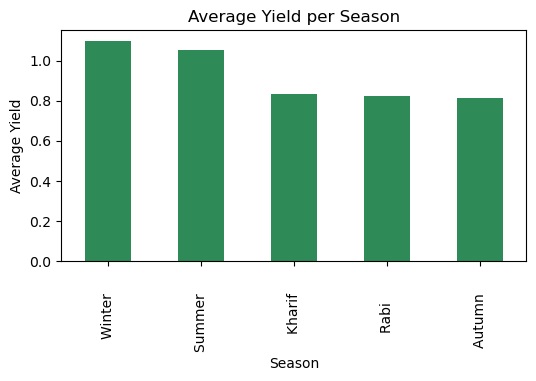

In [36]:
# crops produced whole year have more very large production
yield_per_season = df.groupby('Season')['Yield'].mean().sort_values(ascending=False)

plt.figure(figsize=(6,3))
yield_per_season.drop('Whole Year ').plot(kind='bar', color='seagreen')
plt.title('Average Yield per Season')
plt.xlabel('Season')
plt.ylabel('Average Yield')
plt.show()

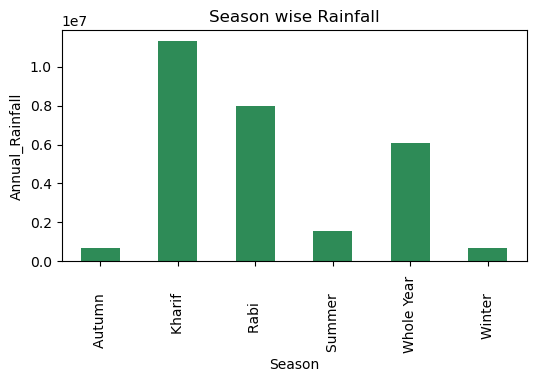

In [198]:
rainfall_season = df.groupby('Season')['Annual_Rainfall'].sum()

plt.figure(figsize=(6,3))
rainfall_season.plot(kind='bar', color='seagreen')
plt.title('Season wise Rainfall')
plt.xlabel('Season')
plt.ylabel('Annual_Rainfall')
plt.show()

#### State level

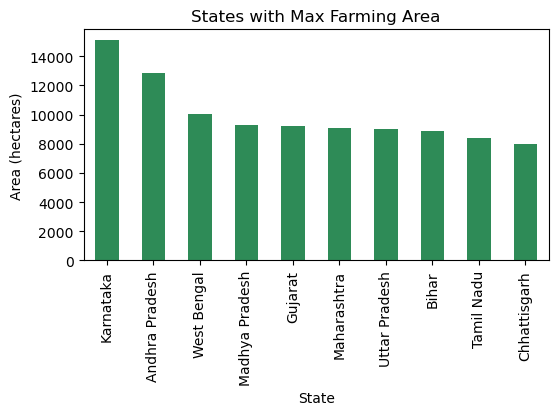

In [37]:
area_per_state = df.groupby('State')['Area'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(6,3))
area_per_state.plot(kind='bar', color='seagreen')
plt.title('States with Max Farming Area')
plt.xlabel('State')
plt.ylabel('Area (hectares)')
plt.show()

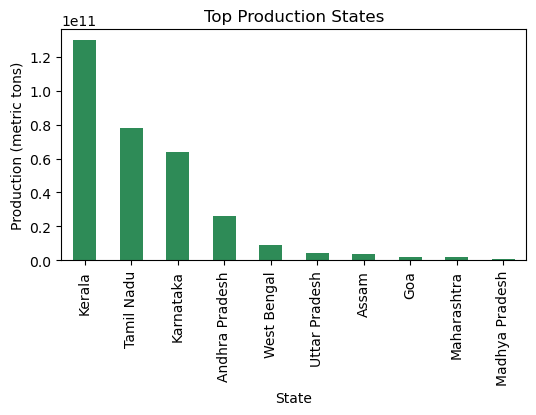

In [38]:
prod_per_state = df.groupby('State')['Production'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(6,3))
prod_per_state.plot(kind='bar', color='seagreen')
plt.title('Top Production States')
plt.xlabel('State')
plt.ylabel('Production (metric tons)')
plt.show()

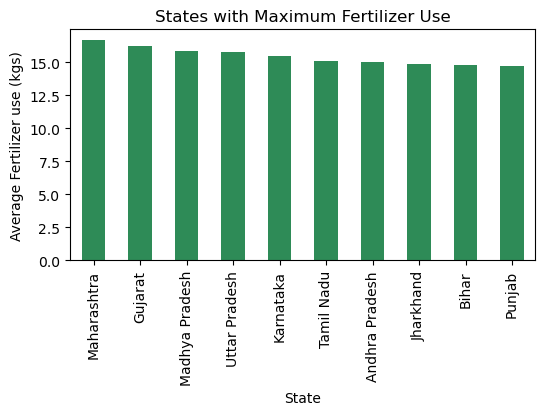

In [39]:
fer_per_state = df.groupby('State')['Fertilizer'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(6,3))
fer_per_state.plot(kind='bar', color='seagreen')
plt.title('States with Maximum Fertilizer Use')
plt.xlabel('State')
plt.ylabel('Average Fertilizer use (kgs)')
plt.show()

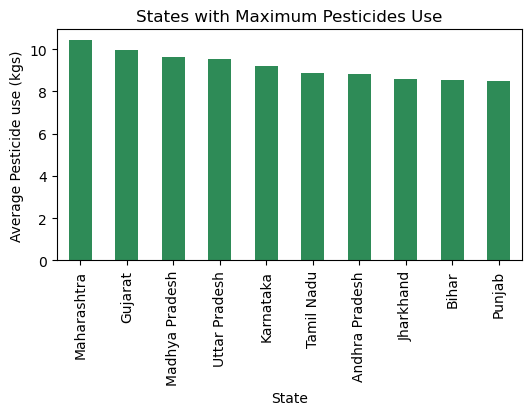

In [40]:
pest_per_state = df.groupby('State')['Pesticide'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(6,3))
pest_per_state.plot(kind='bar', color='seagreen')
plt.title('States with Maximum Pesticides Use')
plt.xlabel('State')
plt.ylabel('Average Pesticide use (kgs)')
plt.show()

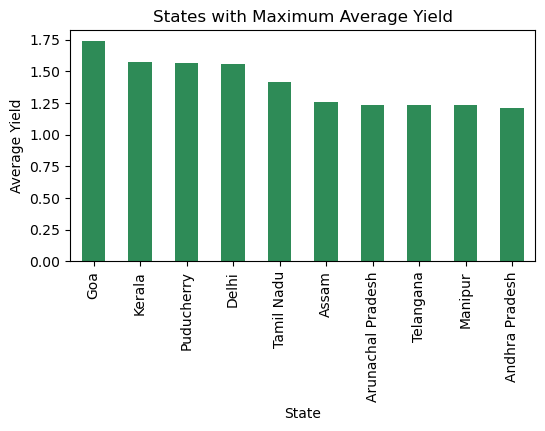

In [41]:
yield_per_state = df.groupby('State')['Yield'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(6,3))
yield_per_state.plot(kind='bar', color='seagreen')
plt.title('States with Maximum Average Yield')
plt.xlabel('State')
plt.ylabel('Average Yield')
plt.show()

### Encoding

In [42]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [43]:
columns_to_encode = ['Crop','State','Season']

for column in columns_to_encode:
    df[column] = le.fit_transform(df[column])
df.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,0,1997,4,2,11.209317,56708,7.626765,15.764969,10.038164,0.585610
1,1,1997,1,2,8.800566,4685,7.626765,13.356082,7.629718,0.536748
2,8,1997,1,2,6.680855,22,7.626765,11.235277,5.512461,0.213766
3,9,1997,4,2,9.886189,126905000,7.626765,14.441803,8.715119,8.563896
4,11,1997,1,2,7.461640,794,7.626765,12.016736,6.291736,0.351297


In [44]:
valid_features = ['Crop','Crop_Year','Season','State','Area','Annual_Rainfall','Fertilizer','Pesticide']

X = df[valid_features]
y = df['Yield']

In [ ]:
#remove production

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

### Model

In [50]:
from sklearn.tree import DecisionTreeRegressor

dr = DecisionTreeRegressor()

In [51]:
dr.fit(X_train, y_train)

DecisionTreeRegressor()

In [52]:
y_pred = dr.predict(X_test)

In [53]:
from sklearn.metrics import r2_score, mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

r2 = r2_score(y_pred, y_test)
print('R2 Score: ',r2)

RMSE: 0.3509253191912426
R2 Score:  0.9021128686128206


In [54]:
n = X_test.shape[0]      #no of samples
p = X_test.shape[1]      #no of features
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
adj_r2

0.9019135565611287

In [55]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()

In [56]:
rf.fit(X_train, y_train)

RandomForestRegressor()

In [57]:
y_pred_rf = rf.predict(X_test)

In [58]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print("RMSE:", rmse)

r2 = r2_score(y_pred_rf, y_test)
print('R2 Score: ',r2)

RMSE: 0.2220763172536344
R2 Score:  0.957138735682189


### Log-Transformation

In [59]:
X = df[valid_features]
y = np.log1p(df['Yield'])

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [61]:
drn = DecisionTreeRegressor()
drn.fit(X_train, y_train)

DecisionTreeRegressor()

In [62]:
y_p = drn.predict(X_test)

In [63]:
rmse = np.sqrt(mean_squared_error(y_test, y_p))
print("RMSE:", rmse)

r2 = r2_score(y_p, y_test)
print('R2 Score: ',r2)

RMSE: 0.1507943078018993
R2 Score:  0.8423104070950195


In [64]:
rfn = RandomForestRegressor()
rfn.fit(X_train, y_train)

RandomForestRegressor()

In [65]:
rfn.fit(X_train, y_train)
y_pred_r = rfn.predict(X_test)

In [66]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred_r))
print("RMSE:", rmse)

r2 = r2_score(y_pred_r, y_test)
print('R2 Score: ',r2)

RMSE: 0.10115172868464198
R2 Score:  0.9170601314539333


In [67]:
## linear regression

In [70]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

r2 = r2_score(y_pred, y_test)
print('R2 Score: ',r2)

RMSE: 0.3542634356854258
R2 Score:  -4.964941018610827
